# Laboratorio

In [1]:
# Import the necessary modules
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits


In [2]:
digits = load_digits(n_class=6)
X, y = digits.data, digits.target
n_samples, n_features = X.shape


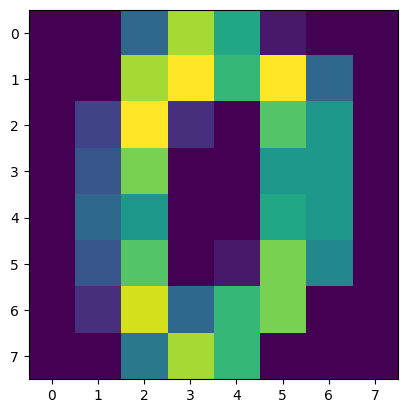

In [3]:
plt.imshow(X[0].reshape(8, 8))

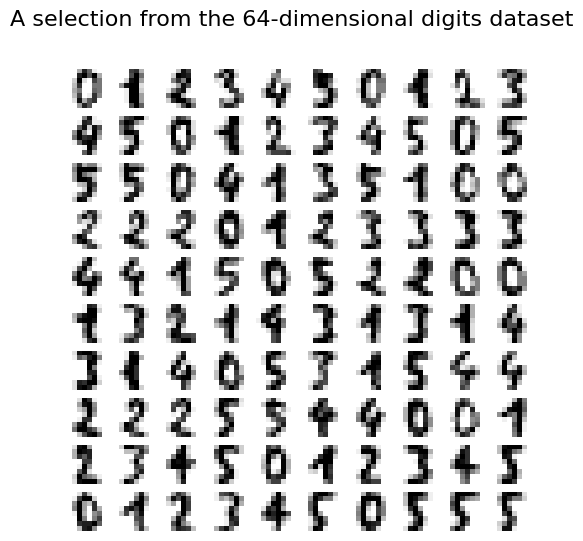

In [4]:
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap=plt.cm.binary)
    ax.axis("off")
_ = fig.suptitle("A selection from the 64-dimensional digits dataset", fontsize=16)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

1. Para el dataset make a moon de sklearn, construir un modelo de una red neuronal con keras para clasificar los datos.

## **Desarrollo**

Shape train_X: (50, 2)
Shape test_X: (950, 2)

Epoch 1/500


c:\Users\ricar\Desktop\FCII\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.7400 - loss: 0.6660 - val_accuracy: 0.6368 - val_loss: 0.6722
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7400 - loss: 0.6639 - val_accuracy: 0.6368 - val_loss: 0.6706
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7600 - loss: 0.6620 - val_accuracy: 0.6432 - val_loss: 0.6690
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7600 - loss: 0.6597 - val_accuracy: 0.6474 - val_loss: 0.6675
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7600 - loss: 0.6576 - val_accuracy: 0.6537 - val_loss: 0.6659
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7600 - loss: 0.6555 - val_accuracy: 0.6526 - val_loss: 0.6644
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7600 - loss: 0.6535 - val_accuracy: 0.6579 - val_loss: 0.6629
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7600 - loss: 0.6515 - val_accuracy: 0.6600 - val_loss: 0.6614
Epo

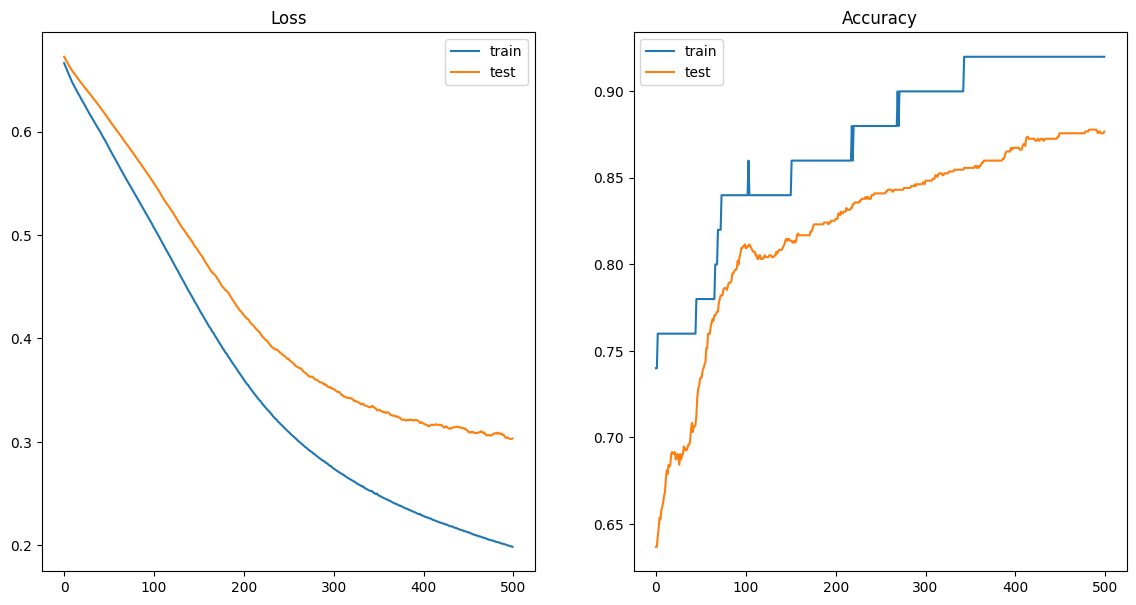

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# =========================
# 1. Generar datos (2D)
# =========================
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# ⚠️ Provocar overfitting: pocos datos de entrenamiento
n_train = 50
train_X, test_X = X[:n_train], X[n_train:]
train_y, test_y = y[:n_train], y[n_train:]

print("Shape train_X:", train_X.shape)  # (50, 2)
print("Shape test_X:", test_X.shape)    # (950, 2)

# =========================
# 2. Modelo grande (alta capacidad)
# =========================
def build_model_overfit(input_dim):
    model = keras.models.Sequential()

    model.add(keras.layers.Dense(64, input_shape=(input_dim,), activation='relu'))
    model.add(keras.layers.Dense(128, activation='relu'))
    model.add(keras.layers.Dense(64, activation='relu'))
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    opt = keras.optimizers.SGD(learning_rate=0.01)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

    return model

keras.backend.clear_session()
model = build_model_overfit(train_X.shape[1])

# =========================
# 3. Entrenamiento
# =========================
history = model.fit(
    train_X, train_y,
    validation_data=(test_X, test_y),
    epochs=500,   # suficiente para ver overfitting
    verbose=1
)

# =========================
# 4. Evaluación
# =========================
_, train_acc = model.evaluate(train_X, train_y, verbose=0)
_, test_acc = model.evaluate(test_X, test_y, verbose=0)

print('Train Accuracy: %.3f' % train_acc)
print('Test Accuracy: %.3f' % test_acc)

# =========================
# 5. Gráficas
# =========================
plt.figure(figsize=(14,7))

# Loss
plt.subplot(121)
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()

# Accuracy
plt.subplot(122)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()

plt.show()

### **Análisis**

Las gráficas evidencian un caso moderado de overfitting en la red neuronal entrenada sobre el dataset make_moons, debido principalmente al uso de una arquitectura relativamente grande (64–128–64 neuronas) frente a un conjunto de entrenamiento muy pequeño (50 muestras) y un número elevado de épocas (500). En la gráfica de pérdida (loss), tanto el error de entrenamiento como el de validación disminuyen inicialmente, indicando que el modelo aprende correctamente la estructura general de los datos; sin embargo, con el avance de las épocas aparece una separación creciente entre ambas curvas, donde la pérdida de entrenamiento continúa disminuyendo más rápidamente que la de validación, señal clara de sobreajuste. De manera similar, la exactitud (accuracy) de entrenamiento alcanza valores cercanos al 92%, mientras que la de validación se estabiliza alrededor del 85–86%, mostrando que el modelo aprende patrones específicos del conjunto de entrenamiento que no generalizan completamente a datos nuevos. No obstante, el sobreajuste no es extremo, ya que la pérdida de validación no aumenta drásticamente y la accuracy de prueba continúa mejorando lentamente, lo cual sugiere que el modelo todavía conserva una capacidad razonable de generalización gracias a la relativa simplicidad geométrica del problema y al uso de SGD, que introduce un efecto regularizador implícito.


2. Para el dataset load digits, construir un modelo de red neuronal empleando keras para realizar la clasificación.

Shape de X: (1797, 64)
Shape de y: (1797,)


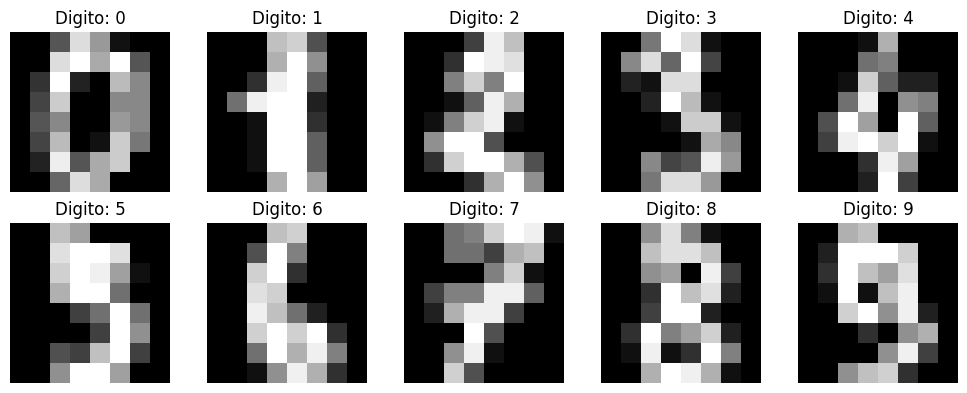


Datos de entrenamiento: (1437, 64)
Datos de prueba: (360, 64)

Resumen del modelo:



c:\Users\ricar\Desktop\FCII\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4148 - loss: 1.8554 - val_accuracy: 0.6833 - val_loss: 1.3268
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7940 - loss: 0.9230 - val_accuracy: 0.8444 - val_loss: 0.6427
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8963 - loss: 0.4636 - val_accuracy: 0.9278 - val_loss: 0.3812
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9415 - loss: 0.2791 - val_accuracy: 0.9361 - val_loss: 0.2744
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9617 - loss: 0.1890 - val_accuracy: 0.9583 - val_loss: 0.2163
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9777 - loss: 0.1378 - val_accuracy: 0.9583 - val_loss: 0.1879
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9798 - loss: 0.1045 - val_accuracy: 0.9639 - val_loss: 0.1726
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9882 - loss: 0.0816 - val_accuracy: 0.9694 - val_loss:

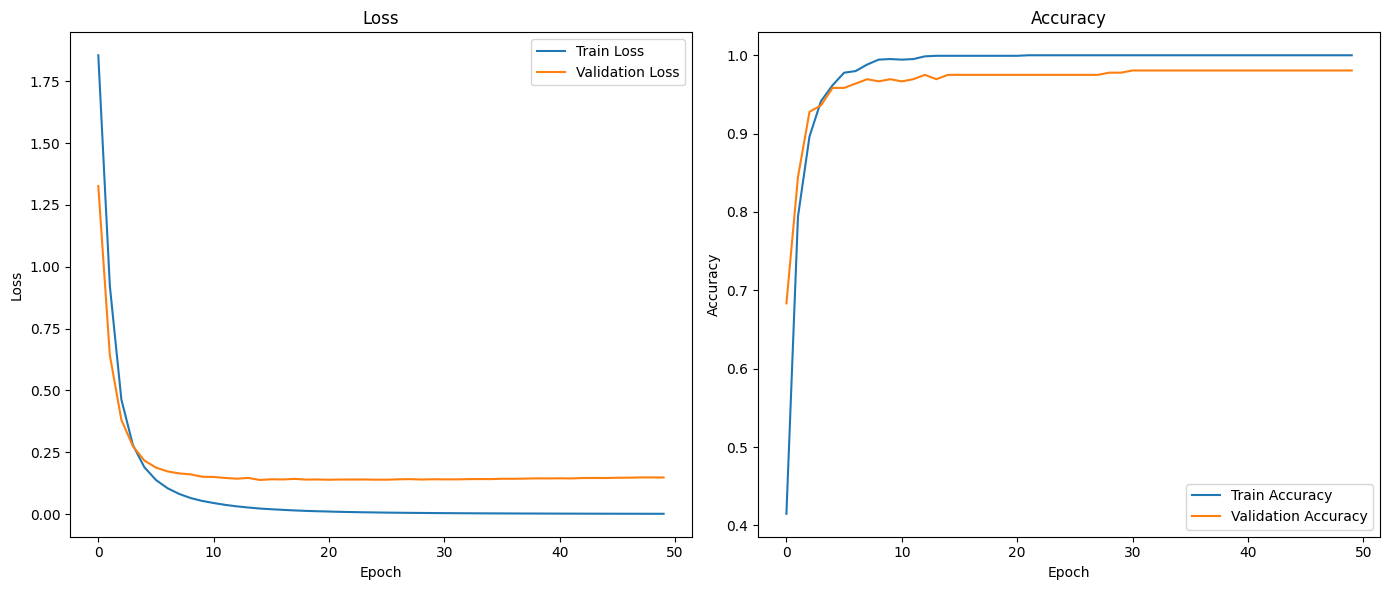

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


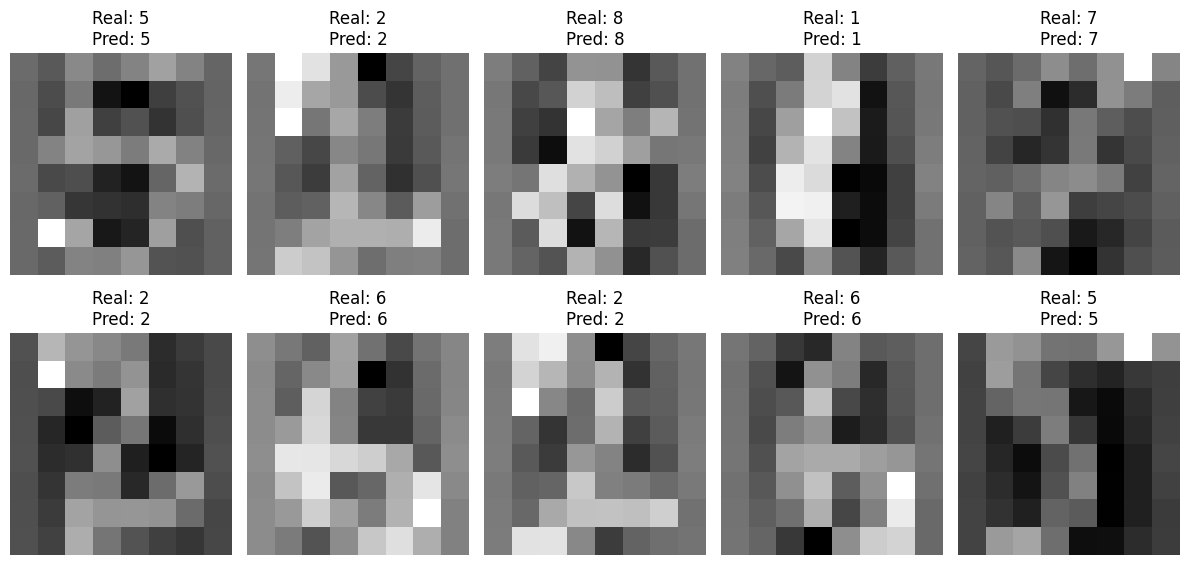

In [7]:
# =========================================================
# CLASIFICACION DEL DATASET LOAD_DIGITS CON KERAS
# =========================================================

# ---------------------------------------------------------
# 1. IMPORTACION DE LIBRERIAS
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras


# ---------------------------------------------------------
# 2. CARGA DEL DATASET
# ---------------------------------------------------------

digits = load_digits()

X = digits.data       # Features (1797 muestras, 64 features)
y = digits.target     # Labels (0-9)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# ---------------------------------------------------------
# 3. VISUALIZACION DE ALGUNAS IMAGENES
# ---------------------------------------------------------

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f'Digito: {y[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. DIVISION TRAIN / TEST
# ---------------------------------------------------------

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nDatos de entrenamiento:", train_X.shape)
print("Datos de prueba:", test_X.shape)


# ---------------------------------------------------------
# 5. NORMALIZACION DE LOS DATOS
# ---------------------------------------------------------

scaler = StandardScaler()

train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)


# ---------------------------------------------------------
# 6. CONSTRUCCION DEL MODELO
# ---------------------------------------------------------

model = keras.models.Sequential()

# Capa de entrada + capa oculta
model.add(
    keras.layers.Dense(
        64,
        activation='relu',
        input_shape=(64,)
    )
)

# Segunda capa oculta
model.add(
    keras.layers.Dense(
        32,
        activation='relu'
    )
)

# Capa de salida
# 10 neuronas -> 10 clases (0-9)
model.add(
    keras.layers.Dense(
        10,
        activation='softmax'
    )
)


# ---------------------------------------------------------
# 7. COMPILACION DEL MODELO
# ---------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ---------------------------------------------------------
# 8. RESUMEN DEL MODELO
# ---------------------------------------------------------

print("\nResumen del modelo:\n")
model.summary()


# ---------------------------------------------------------
# 9. ENTRENAMIENTO
# ---------------------------------------------------------

history = model.fit(
    train_X,
    train_y,
    validation_data=(test_X, test_y),
    epochs=50,
    batch_size=32,
    verbose=1
)


# ---------------------------------------------------------
# 10. EVALUACION DEL MODELO
# ---------------------------------------------------------

train_loss, train_acc = model.evaluate(train_X, train_y, verbose=0)
test_loss, test_acc = model.evaluate(test_X, test_y, verbose=0)

print("\n===================================")
print("RESULTADOS FINALES")
print("===================================")

print(f"Accuracy entrenamiento: {train_acc:.4f}")
print(f"Accuracy prueba:        {test_acc:.4f}")


# ---------------------------------------------------------
# 11. GRAFICAS
# ---------------------------------------------------------

plt.figure(figsize=(14,6))

# ---------------- LOSS ----------------

plt.subplot(1,2,1)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

# ---------------- ACCURACY ----------------

plt.subplot(1,2,2)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 12. PREDICCIONES
# ---------------------------------------------------------

predicciones = model.predict(test_X)

# Clase predicha
pred_classes = np.argmax(predicciones, axis=1)

# ---------------------------------------------------------
# 13. VISUALIZACION DE PREDICCIONES
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    imagen = test_X[i].reshape(8,8)

    plt.imshow(imagen, cmap='gray')

    plt.title(
        f"Real: {test_y[i]}\nPred: {pred_classes[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## **Análisis**

Los resultados obtenidos muestran que la red neuronal implementada para el dataset load_digits logra un desempeño altamente satisfactorio en la tarea de clasificación multiclase de dígitos manuscritos. En las gráficas de entrenamiento se observa que tanto la pérdida (loss) de entrenamiento como la de validación disminuyen rápidamente durante las primeras épocas, indicando que el modelo aprende de manera eficiente las características relevantes de las imágenes; posteriormente, la pérdida de entrenamiento continúa acercándose a cero mientras que la pérdida de validación se estabiliza alrededor de un valor bajo (~0.15), evidenciando una ligera separación entre ambas curvas que sugiere un sobreajuste moderado, aunque no severo, ya que la accuracy de validación permanece cercana al 98%. La gráfica de exactitud muestra que el modelo alcanza rápidamente valores superiores al 95% tanto en entrenamiento como en validación, llegando incluso a una accuracy de entrenamiento prácticamente perfecta, lo cual confirma que la arquitectura empleada posee suficiente capacidad para modelar adecuadamente el problema. Además, las visualizaciones de las imágenes y de las predicciones evidencian que el modelo clasifica correctamente los ejemplos mostrados, asignando la etiqueta adecuada a cada dígito manuscrito. En conjunto, los resultados indican que la red neuronal logra una excelente capacidad de aprendizaje y generalización sobre el dataset load_digits, obteniendo una clasificación precisa y estable.
